In [ ]:
from io import StringIO
from textwrap import dedent

import pandas as pd
import matplotlib.pyplot as plt

from google import genai
from stemmer import Stemmer

## Stemming

In [2]:
stemmer = Stemmer("../data/sundabaru1-vocab.txt")

In [3]:
df = pd.read_csv("../data/data_uji_stemming.csv", encoding="latin-1")
df.head()

,token,kata_dasar
0,kasenian,seni
1,tradisional,tradisi
2,nyaeta,eta
3,kasenian,seni
4,anu,anu


In [4]:
df["stem"] = df["token"].apply(lambda x: stemmer.stem_ams(x))
df["correct"] = df["stem"].str.lower() == df["kata_dasar"].str.lower()

df.head()

,token,kata_dasar,stem,correct
0,kasenian,seni,kasenén,False
1,tradisional,tradisi,tradisional,False
2,nyaeta,eta,nyeta,False
3,kasenian,seni,kasenén,False
4,anu,anu,anu,True


In [5]:
print("Accuracy:", df["correct"].mean())

Accuracy: 0.7326007326007326


In [6]:
df.to_csv("hasil_stemming.csv", index=False, encoding='utf-8')

## LLM Judge

In [ ]:
client = genai.Client(api_key="---KEY-HERE---")

In [25]:
df_inspect = df[~df["correct"]].copy().rename(columns={"token": "word", "kata_dasar": "correct_base", "stem": "stemmed"}).drop(columns=["correct"])
df_inspect["id"] = range(len(df_inspect))

df_inspect = df_inspect[["id", "word", "correct_base", "stemmed"]]

df_inspect.head()

,id,word,correct_base,stemmed
0,0,kasenian,seni,kasenén
1,1,tradisional,tradisi,tradisional
2,2,nyaeta,eta,nyeta
3,3,kasenian,seni,kasenén
9,4,kabiasaan,biasa,bésa


In [26]:
df.shape, df_inspect.shape

((546, 4), (146, 4))

In [27]:
data_str = df_inspect.to_csv(index=None)
print(data_str[:200])

id,word,correct_base,stemmed
0,kasenian,seni,kasenén
1,tradisional,tradisi,tradisional
2,nyaeta,eta,nyeta
3,kasenian,seni,kasenén
4,kabiasaan,biasa,bésa
5,kasenian,seni,kasenén
6,jaipongan,jaipong,jai


In [28]:
SYSTEM_INSTRUCTION = dedent("""
                            You are a Sundanese language expert designed to judge a stemming algorithm output.
                            You will be given a list of triplet of a word in Sundanese: the original word, the correct base word, and the stemmed word.
                            You job is to classify the stemmed word into one of the three categories:
                            - "unknown" if the stemmed word is not a valid Sundanese word
                            - "overstemmed" if the stemmed word has too many missing letters or resulting in invalid word
                            - "understemmed" if the stemmed word have not removed all of the affixes
                            - "correct" if the stemmed word is the same as the correct base word
                            Only return the id and classification without any additional text in a CSV format.
                            The stemmed word MUST BE a valid Sundanese word to be considered correct.

                            Example:
                            Input: 0,kasenian,seni,kasenén
                            Output: 0,understemmed
                            """)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    config=genai.types.GenerateContentConfig(system_instruction=SYSTEM_INSTRUCTION, temperature=0.2),
    contents=data_str,
)

print(response.text)

0,overstemmed
1,understemmed
2,understemmed
3,overstemmed
4,overstemmed
5,overstemmed
6,understemmed
7,overstemmed
8,understemmed
9,overstemmed
10,overstemmed
11,overstemmed
12,understemmed
13,understemmed
14,overstemmed
15,understemmed
16,understemmed
17,overstemmed
18,understemmed
19,understemmed
20,understemmed
21,overstemmed
22,overstemmed
23,understemmed
24,understemmed
25,overstemmed
26,understemmed
27,understemmed
28,understemmed
29,overstemmed
30,understemmed
31,overstemmed
32,understemmed
33,overstemmed
34,overstemmed
35,understemmed
36,understemmed
37,overstemmed
38,understemmed
39,overstemmed
40,understemmed
41,understemmed
42,understemmed
43,understemmed
44,overstemmed
45,overstemmed
46,understemmed
47,understemmed
48,understemmed
49,overstemmed
50,understemmed
51,understemmed
52,overstemmed
53,understemmed
54,overstemmed
55,understemmed
56,understemmed
57,understemmed
58,understemmed
59,understemmed
60,understemmed
61,understemmed
62,understemmed
63,understemmed
64,overste

In [33]:
df_result = pd.read_csv(StringIO(response.text), names=["id", "classification"])
df_result.head()

,id,classification
0,0,overstemmed
1,1,understemmed
2,2,understemmed
3,3,overstemmed
4,4,overstemmed


In [36]:
df_judge = df_inspect.merge(df_result, on="id")
df_judge.head()

,id,word,correct_base,stemmed,classification
0,0,kasenian,seni,kasenén,overstemmed
1,1,tradisional,tradisi,tradisional,understemmed
2,2,nyaeta,eta,nyeta,understemmed
3,3,kasenian,seni,kasenén,overstemmed
4,4,kabiasaan,biasa,bésa,overstemmed


In [37]:
df_judge.to_csv("hasil_stemming_judge.csv", index=False)

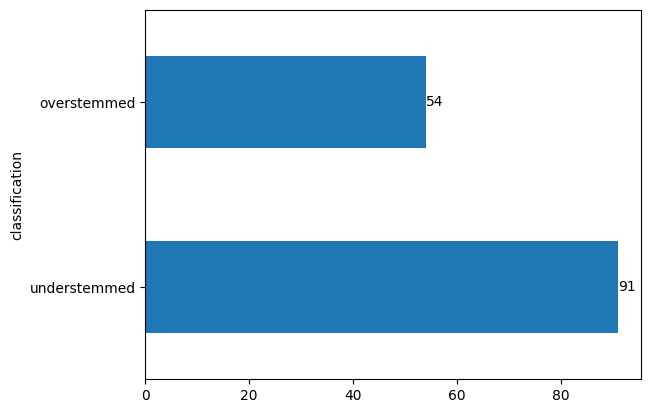

In [42]:
ax = df_judge[df_judge["classification"] != "correct"]["classification"].value_counts().plot(kind="barh")
ax.bar_label(ax.containers[0])

plt.show()